Welcome to VegasIQ
1. Las Vegas Events Database
2. Las Vegas Weather Data
3. Action 3
4. Action 4
5. Action 5
6. User Management
7. System Exit


Select an option:  2



Weather Dashboard Main Menu
1. Current Weather
2. Forecast Weather
3. Monthly Weather
4. Exit to Main Menu


Please enter menu selection (1 - 4):  1


Current weather in Las Vegas
Description: clear sky
Temperature: 57.15°F
Feels like: 53.78°F
Humidity: 26%

Weather Dashboard Main Menu
1. Current Weather
2. Forecast Weather
3. Monthly Weather
4. Exit to Main Menu


Please enter menu selection (1 - 4):  2



Summary of Forecast Weather:
Average Temperature: 52.81°F
Average Humidity: 16.30%
Average Wind Speed: 2.88 mph
Temperature Range: 42.04°F - 68.05°F
Humidity Range: 8.00% - 27.00%
Wind Speed Range: 1.34 mph - 4.79 mph


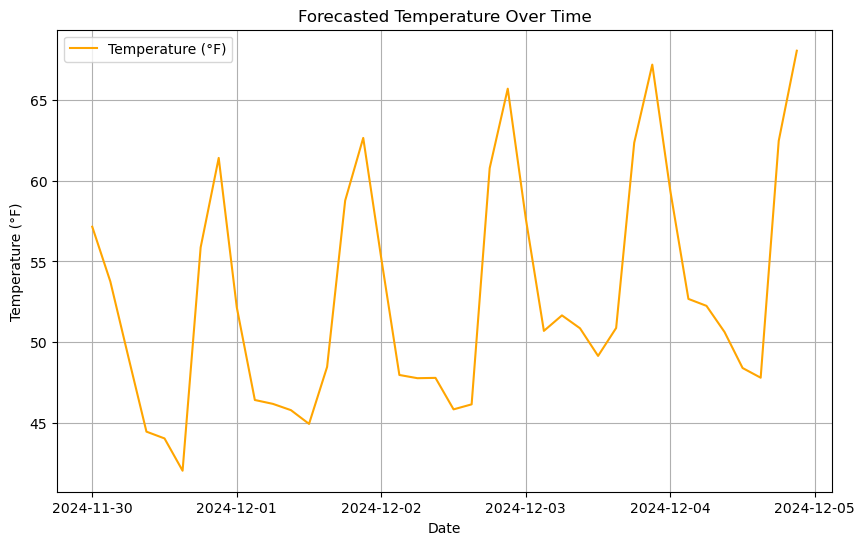

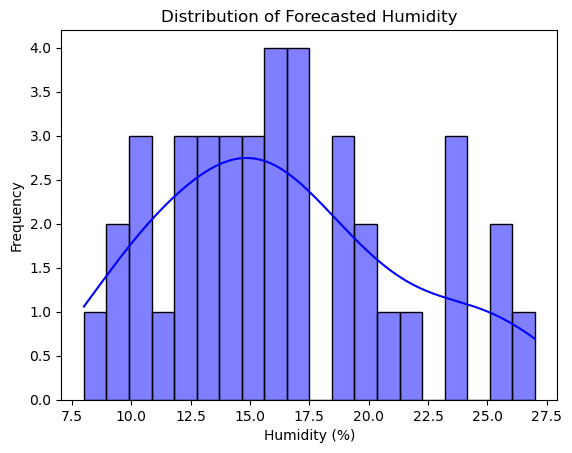

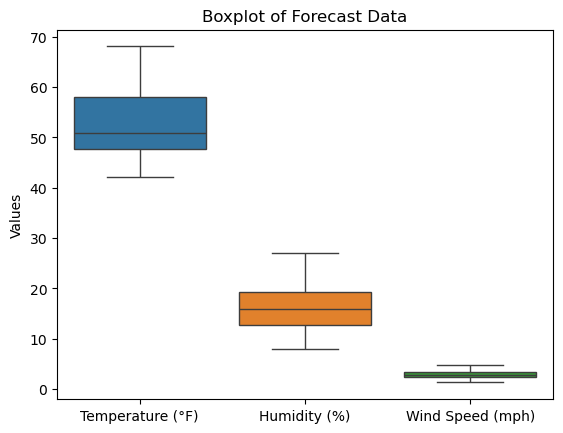


Weather Dashboard Main Menu
1. Current Weather
2. Forecast Weather
3. Monthly Weather
4. Exit to Main Menu


Please enter menu selection (1 - 4):  3



Summary of Monthly Weather Estimate (Based on 5-Day Forecast):
Average Temperature: 52.81°F
Average Humidity: 16.30%
Average Wind Speed: 2.88 mph
Temperature Range: 42.04°F - 68.05°F
Humidity Range: 8.00% - 27.00%
Wind Speed Range: 1.34 mph - 4.79 mph


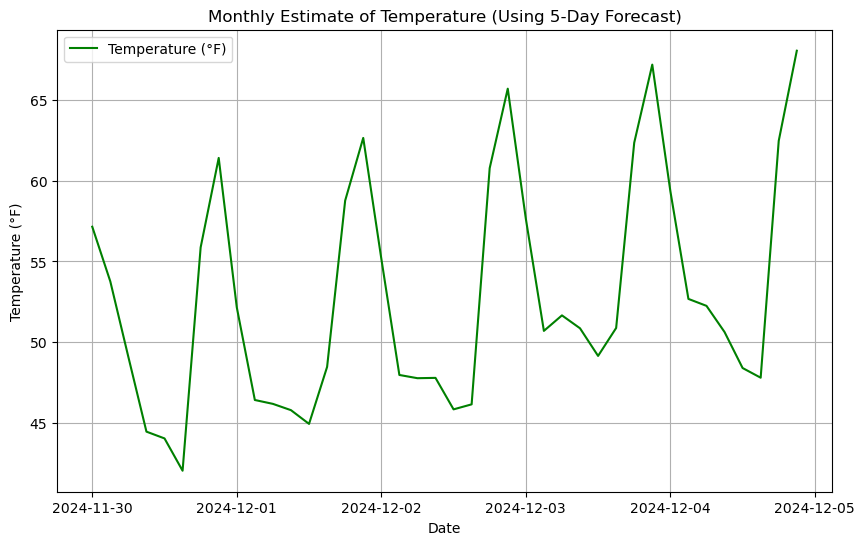

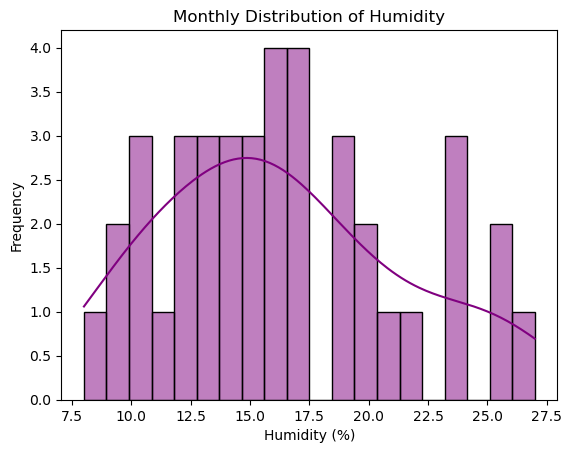

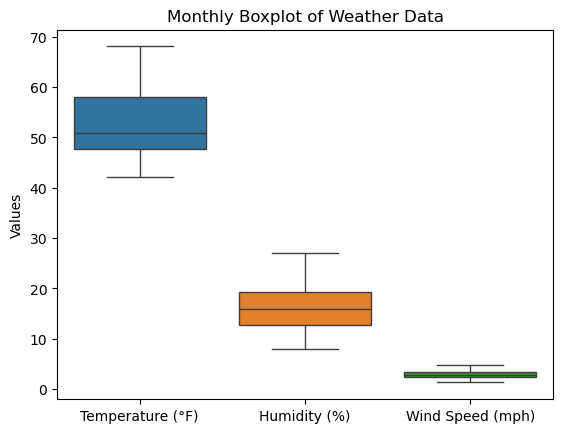


Weather Dashboard Main Menu
1. Current Weather
2. Forecast Weather
3. Monthly Weather
4. Exit to Main Menu


Please enter menu selection (1 - 4):  4


Returning to Main Menu.
Welcome to VegasIQ
1. Las Vegas Events Database
2. Las Vegas Weather Data
3. Action 3
4. Action 4
5. Action 5
6. User Management
7. System Exit


In [ ]:
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Please enter your OpenWeatherMap API Key here
APPID = '3741775b9523fb5654ad764de205b071'

# Assume the location to be Las Vegas, NV, US
location = 'Las Vegas, NV, US'

def main_menu():
    # Function to get weather data from OpenWeatherMap API
    def get_weather_data(endpoint, params):
        url = f'https://api.openweathermap.org/data/2.5/{endpoint}'
        params['q'] = location
        params['appid'] = APPID
        params['units'] = 'Imperial'
        response = requests.get(url, params=params)
        response.raise_for_status()
        return json.loads(response.text)

    # Function to display current weather
    def display_current_weather():
        weather_data = get_weather_data('weather', {})
        print('Current weather in', weather_data['name'])
        weather_sec = weather_data['weather'][0]['description']
        main_sec = weather_data['main']
        print(f"Description: {weather_sec}")
        print(f"Temperature: {main_sec['temp']}\u00b0F")
        print(f"Feels like: {main_sec['feels_like']}\u00b0F")
        print(f"Humidity: {main_sec['humidity']}%")

    # Function to display and summarize forecast weather
    def display_forecast_weather():
        forecast_data = get_weather_data('forecast', {'cnt': 40})  # 5-day forecast
        dates = [item['dt_txt'] for item in forecast_data['list']]
        temperatures = [item['main']['temp'] for item in forecast_data['list']]
        humidities = [item['main']['humidity'] for item in forecast_data['list']]
        wind_speeds = [item['wind']['speed'] for item in forecast_data['list']]

        forecast_df = pd.DataFrame({
            'Date': pd.to_datetime(dates),
            'Temperature (\u00b0F)': temperatures,
            'Humidity (%)': humidities,
            'Wind Speed (mph)': wind_speeds
        })

        # Summarize the forecast weather
        print("\nSummary of Forecast Weather:")
        print(f"Average Temperature: {forecast_df['Temperature (\u00b0F)'].mean():.2f}\u00b0F")
        print(f"Average Humidity: {forecast_df['Humidity (%)'].mean():.2f}%")
        print(f"Average Wind Speed: {forecast_df['Wind Speed (mph)'].mean():.2f} mph")
        print(f"Temperature Range: {forecast_df['Temperature (\u00b0F)'].min():.2f}\u00b0F - {forecast_df['Temperature (\u00b0F)'].max():.2f}\u00b0F")
        print(f"Humidity Range: {forecast_df['Humidity (%)'].min():.2f}% - {forecast_df['Humidity (%)'].max():.2f}%")
        print(f"Wind Speed Range: {forecast_df['Wind Speed (mph)'].min():.2f} mph - {forecast_df['Wind Speed (mph)'].max():.2f} mph")

        # Visualization
        plt.figure(figsize=(10, 6))
        plt.plot(forecast_df['Date'], forecast_df['Temperature (\u00b0F)'], label='Temperature (\u00b0F)', color='orange')
        plt.title('Forecasted Temperature Over Time')
        plt.xlabel('Date')
        plt.ylabel('Temperature (\u00b0F)')
        plt.legend()
        plt.grid()
        plt.show()

        sns.histplot(forecast_df['Humidity (%)'], kde=True, bins=20, color='blue')
        plt.title('Distribution of Forecasted Humidity')
        plt.xlabel('Humidity (%)')
        plt.ylabel('Frequency')
        plt.show()

        sns.boxplot(data=forecast_df[['Temperature (\u00b0F)', 'Humidity (%)', 'Wind Speed (mph)']])
        plt.title('Boxplot of Forecast Data')
        plt.xticks([0, 1, 2], ['Temperature (\u00b0F)', 'Humidity (%)', 'Wind Speed (mph)'])
        plt.ylabel('Values')
        plt.show()

    # Function to display and summarize monthly weather (using the 5-day forecast as an estimate)
    def display_monthly_weather():
        forecast_data = get_weather_data('forecast', {'cnt': 40})  # 5-day forecast
        dates = [item['dt_txt'] for item in forecast_data['list']]
        temperatures = [item['main']['temp'] for item in forecast_data['list']]
        humidities = [item['main']['humidity'] for item in forecast_data['list']]
        wind_speeds = [item['wind']['speed'] for item in forecast_data['list']]

        forecast_df = pd.DataFrame({
            'Date': pd.to_datetime(dates),
            'Temperature (\u00b0F)': temperatures,
            'Humidity (%)': humidities,
            'Wind Speed (mph)': wind_speeds
        })

        # Summarize the monthly weather
        avg_temp = forecast_df['Temperature (\u00b0F)'].mean()
        avg_humidity = forecast_df['Humidity (%)'].mean()
        avg_wind_speed = forecast_df['Wind Speed (mph)'].mean()

        print("\nSummary of Monthly Weather Estimate (Based on 5-Day Forecast):")
        print(f"Average Temperature: {avg_temp:.2f}\u00b0F")
        print(f"Average Humidity: {avg_humidity:.2f}%")
        print(f"Average Wind Speed: {avg_wind_speed:.2f} mph")
        print(f"Temperature Range: {forecast_df['Temperature (\u00b0F)'].min():.2f}\u00b0F - {forecast_df['Temperature (\u00b0F)'].max():.2f}\u00b0F")
        print(f"Humidity Range: {forecast_df['Humidity (%)'].min():.2f}% - {forecast_df['Humidity (%)'].max():.2f}%")
        print(f"Wind Speed Range: {forecast_df['Wind Speed (mph)'].min():.2f} mph - {forecast_df['Wind Speed (mph)'].max():.2f} mph")

        # Visualization
        plt.figure(figsize=(10, 6))
        plt.plot(forecast_df['Date'], forecast_df['Temperature (\u00b0F)'], label='Temperature (\u00b0F)', color='green')
        plt.title('Monthly Estimate of Temperature (Using 5-Day Forecast)')
        plt.xlabel('Date')
        plt.ylabel('Temperature (\u00b0F)')
        plt.legend()
        plt.grid()
        plt.show()

        sns.histplot(forecast_df['Humidity (%)'], kde=True, bins=20, color='purple')
        plt.title('Monthly Distribution of Humidity')
        plt.xlabel('Humidity (%)')
        plt.ylabel('Frequency')
        plt.show()

        sns.boxplot(data=forecast_df[['Temperature (\u00b0F)', 'Humidity (%)', 'Wind Speed (mph)']])
        plt.title('Monthly Boxplot of Weather Data')
        plt.xticks([0, 1, 2], ['Temperature (\u00b0F)', 'Humidity (%)', 'Wind Speed (mph)'])
        plt.ylabel('Values')
        plt.show()

    # Main menu function to display options and link to weather dashboard
    def weather_dashboard_menu():
        while True:
            print("\nWeather Dashboard Main Menu")
            print("1. Current Weather")
            print("2. Forecast Weather")
            print("3. Monthly Weather")
            print("4. Exit to Main Menu")

            menu_input = input("Please enter menu selection (1 - 4): ")

            if menu_input == "1":
                display_current_weather()
            elif menu_input == "2":
                display_forecast_weather()
            elif menu_input == "3":
                display_monthly_weather()
            elif menu_input == "4":
                print("Returning to Main Menu.")
                break
            else:
                print("Invalid choice. Please try again.")

    # Function to clear screen
    def clear_screen():
        """Clears the terminal screen for better user experience."""
        os.system('cls' if os.name == 'nt' else 'clear')

    # Main program loop for VegasIQ
    while True:
        clear_screen()
        print("Welcome to VegasIQ")
        print("===================")
        print("1. Las Vegas Events Database")
        print("2. Las Vegas Weather Data")
        print("3. Action 3")
        print("4. Action 4")
        print("5. Action 5")
        print("6. User Management")
        print("7. System Exit")
        choice = input("Select an option: ")

        if choice == "1":
            print("Las Vegas Events Database functionality coming soon.")
        elif choice == "2":
            weather_dashboard_menu()
        elif choice == "3":
            print("Action 3 functionality coming soon.")
        elif choice == "4":
            print("Action 4 functionality coming soon.")
        elif choice == "5":
            print("Action 5 functionality coming soon.")
        elif choice == "6":
            print("User Management functionality coming soon.")
        elif choice == "7":
            clear_screen()
            print("Thank you for using VegasIQ!")
            break
        else:
            print("Invalid choice. Please try again.")

if __name__ == "__main__":
    main_menu()
